# 09 - Ensino Superior: Matrículas por Área, Estado e Ano (2022–2024)

Este notebook analisa os dados do Censo da Educação Superior de 2022 a 2024,
agrupando matrículas por área geral do CINE (`NO_CINE_AREA_GERAL`), estado e ano.

- **Fonte:** Microdados do Censo da Educação Superior (INEP)
- **Período:** 2022, 2023, 2024
- **Leitura:** Polars (mesclagem e agregação)
- **Visualização:** Pandas + Matplotlib/Seaborn

In [1]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

plt.rcParams['figure.figsize'] = (14, 8)
sns.set_palette('husl')

data_dir = '../data'
print('Bibliotecas importadas com sucesso.')

Bibliotecas importadas com sucesso.


## 1. Carregar dados de Ensino Superior (2022–2024) com Polars

In [2]:
def carregar_ensino_superior_polars(ano):
    """Carrega dados do Censo da Educação Superior usando Polars."""
    if ano == 2022:
        base_dir = f'{data_dir}/microdados_censo_da_educacao_superior_2022/microdados_educaç╞o_superior_2022/dados'
    else:
        base_dir = f'{data_dir}/microdados_censo_da_educacao_superior_{ano}/dados'
    
    # Ler IES (para obter SG_UF_IES)
    ies = pl.read_csv(
        f'{base_dir}/MICRODADOS_ED_SUP_IES_{ano}.CSV',
        separator=';',
        encoding='latin-1',
        columns=['CO_IES', 'SG_UF_IES']
    )
    
    # Ler cursos (para obter área e matrículas)
    cursos = pl.read_csv(
        f'{base_dir}/MICRODADOS_CADASTRO_CURSOS_{ano}.CSV',
        separator=';',
        encoding='latin-1',
        columns=['CO_IES', 'NO_CINE_AREA_GERAL', 'QT_MAT'],
        low_memory=True
    )
    
    # Merge entre IES e cursos
    merged = cursos.join(ies, on='CO_IES', how='left')
    
    # Agrupar por área e estado, somando matrículas
    df_agrupado = merged.group_by(['NO_CINE_AREA_GERAL', 'SG_UF_IES']).agg(
        pl.col('QT_MAT').sum().alias('QT_MAT')
    ).rename({'SG_UF_IES': 'SG_UF'})
    
    # Adicionar coluna de ano
    df_agrupado = df_agrupado.with_columns(pl.lit(ano).alias('ANO'))
    
    return df_agrupado

# Carregar todos os anos
dfs = []
for ano in [2022, 2023, 2024]:
    df_ano = carregar_ensino_superior_polars(ano)
    dfs.append(df_ano)
    print(f'{ano}: {len(df_ano)} registros (área × estado) carregados')

# Concatenar todos os anos
df_polars = pl.concat(dfs)
print(f'\nTotal consolidado: {len(df_polars)} registros')
df_polars.head()

2022: 288 registros (área × estado) carregados
2023: 290 registros (área × estado) carregados
2024: 291 registros (área × estado) carregados

Total consolidado: 869 registros


NO_CINE_AREA_GERAL,SG_UF,QT_MAT,ANO
str,str,i64,i32
"""Engenharia, produção e constru…","""BA""",30479,2022
"""Computação e Tecnologias da In…","""MA""",3195,2022
"""Serviços""","""AL""",992,2022
"""Engenharia, produção e constru…","""AL""",6332,2022
"""Agricultura, silvicultura, pes…","""RN""",3774,2022


## 2. Converter para Pandas e visualizar estrutura

In [3]:
# Converter para pandas
df = df_polars.to_pandas()

# Garantir tipos numéricos
df['QT_MAT'] = pd.to_numeric(df['QT_MAT'], errors='coerce').fillna(0).astype(int)

print(f'Dimensão do DataFrame: {df.shape}')
print(f'\nColunas: {df.columns.tolist()}')
print(f'\nAnos: {sorted(df["ANO"].unique())}')
print(f'Estados: {sorted(df["SG_UF"].unique())}')
print(f'\nÁreas gerais disponíveis:')
for area in sorted(df['NO_CINE_AREA_GERAL'].unique()):
    print(f'  - {area}')

df.head(10)

Dimensão do DataFrame: (869, 4)

Colunas: ['NO_CINE_AREA_GERAL', 'SG_UF', 'QT_MAT', 'ANO']

Anos: [np.int32(2022), np.int32(2023), np.int32(2024)]
Estados: ['AC', 'AL', 'AM', 'AP', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MG', 'MS', 'MT', 'PA', 'PB', 'PE', 'PI', 'PR', 'RJ', 'RN', 'RO', 'RR', 'RS', 'SC', 'SE', 'SP', 'TO']

Áreas gerais disponíveis:
  - Agricultura, silvicultura, pesca e veterinária
  - Artes e humanidades
  - Ciências naturais, matemática e estatística
  - Ciências sociais, comunicação e informação
  - Computação e Tecnologias da Informação e Comunicação (TIC)
  - Educação
  - Engenharia, produção e construção
  - Negócios, administração e direito
  - Programas básicos
  - Saúde e bem-estar
  - Serviços


,NO_CINE_AREA_GERAL,SG_UF,QT_MAT,ANO
0,"Engenharia, produção e construção",BA,30479,2022
1,Computação e Tecnologias da Informação e Comun...,MA,3195,2022
2,Serviços,AL,992,2022
3,"Engenharia, produção e construção",AL,6332,2022
4,"Agricultura, silvicultura, pesca e veterinária",RN,3774,2022
5,Computação e Tecnologias da Informação e Comun...,SE,3041,2022
6,Computação e Tecnologias da Informação e Comun...,MS,9235,2022
7,Educação,ES,14469,2022
8,Programas básicos,AC,135,2022
9,Serviços,RR,114,2022


## 3. Matrículas por Área Geral (Brasil, total 2022–2024)

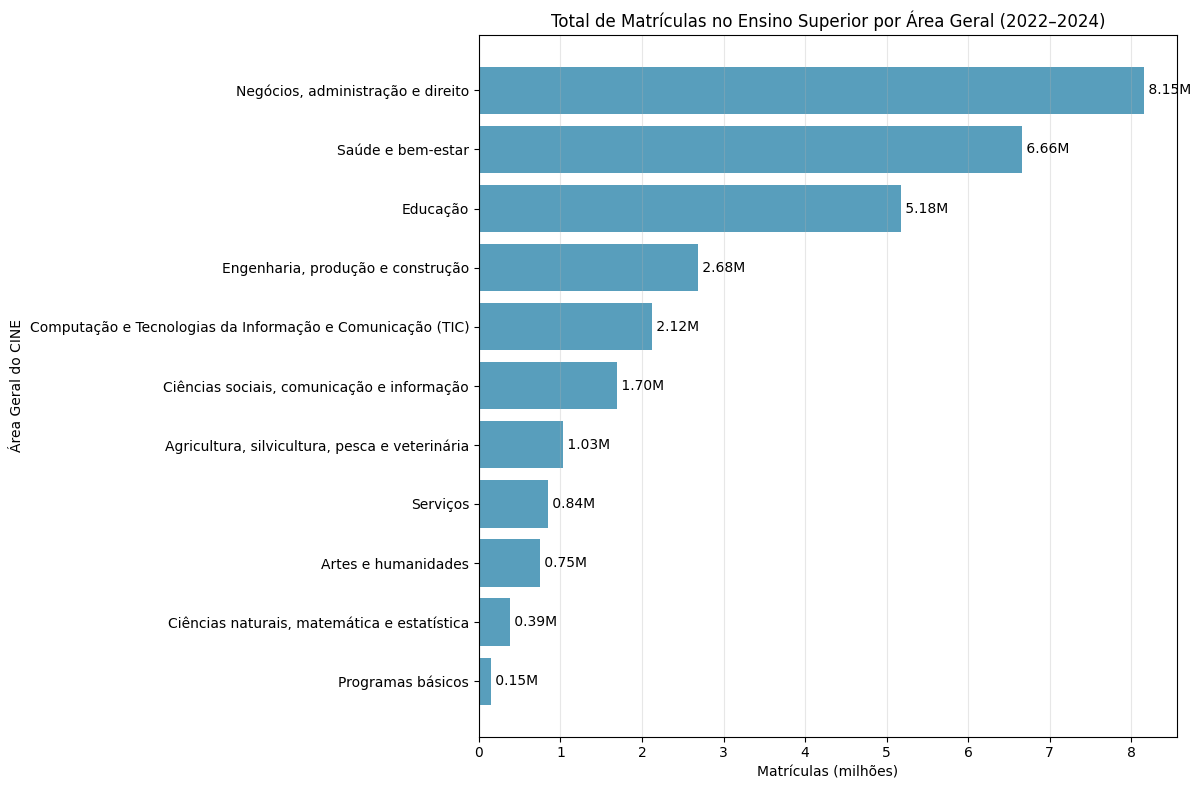


Total de matrículas por área:
Negócios, administração e direito: 8,154,036
Saúde e bem-estar: 6,655,534
Educação: 5,180,471
Engenharia, produção e construção: 2,683,330
Computação e Tecnologias da Informação e Comunicação (TIC): 2,119,287
Ciências sociais, comunicação e informação: 1,698,752
Agricultura, silvicultura, pesca e veterinária: 1,030,632
Serviços: 842,555
Artes e humanidades: 750,373
Ciências naturais, matemática e estatística: 386,108
Programas básicos: 147,521


In [4]:
# Total de matrículas por área (somando todos os anos e estados)
mat_area = df.groupby('NO_CINE_AREA_GERAL')['QT_MAT'].sum().sort_values(ascending=True)

plt.figure(figsize=(12, 8))
bars = plt.barh(mat_area.index, mat_area.values / 1_000_000, color='#2E86AB', alpha=0.8)
plt.xlabel('Matrículas (milhões)')
plt.ylabel('Área Geral do CINE')
plt.title('Total de Matrículas no Ensino Superior por Área Geral (2022–2024)')
plt.grid(axis='x', alpha=0.3)

# Adicionar valores nas barras
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,
             f' {width:.2f}M',
             ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print('\nTotal de matrículas por área:')
for area, total in mat_area.sort_values(ascending=False).items():
    print(f'{area}: {total:,.0f}')

## 4. Matrículas por Área Geral e Ano

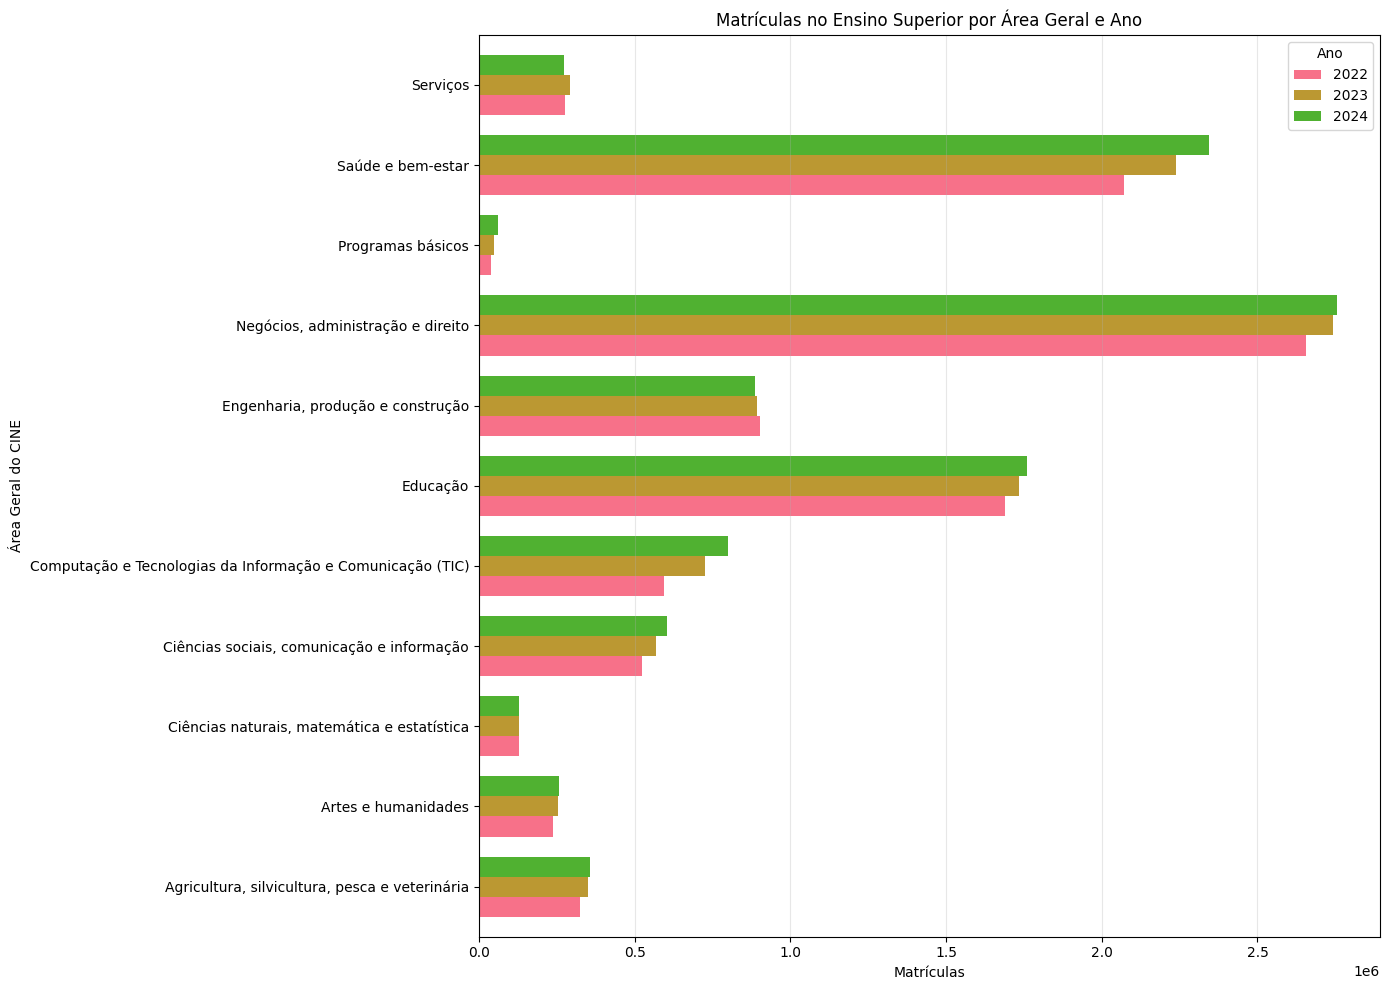

Tabela - Matrículas por Área e Ano:


ANO,2022,2023,2024
NO_CINE_AREA_GERAL,,,
"Agricultura, silvicultura, pesca e veterinária",325015,349597,356020
Artes e humanidades,238724,254521,257128
"Ciências naturais, matemática e estatística",129425,128240,128443
"Ciências sociais, comunicação e informação",524916,568943,604893
Computação e Tecnologias da Informação e Comunicação (TIC),594580,724485,800222
Educação,1687809,1734150,1758512
"Engenharia, produção e construção",903081,892728,887521
"Negócios, administração e direito",2655174,2743122,2755740
Programas básicos,38004,48464,61053


In [5]:
# Pivot: área × ano
pivot_area_ano = df.pivot_table(
    index='NO_CINE_AREA_GERAL',
    columns='ANO',
    values='QT_MAT',
    aggfunc='sum',
    fill_value=0
).astype(int)

# Gráfico de barras agrupadas
pivot_area_ano.plot(kind='barh', figsize=(14, 10), width=0.75)
plt.xlabel('Matrículas')
plt.ylabel('Área Geral do CINE')
plt.title('Matrículas no Ensino Superior por Área Geral e Ano')
plt.legend(title='Ano')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('Tabela - Matrículas por Área e Ano:')
display(pivot_area_ano)

## 5. Matrículas por Estado (total 2022–2024)

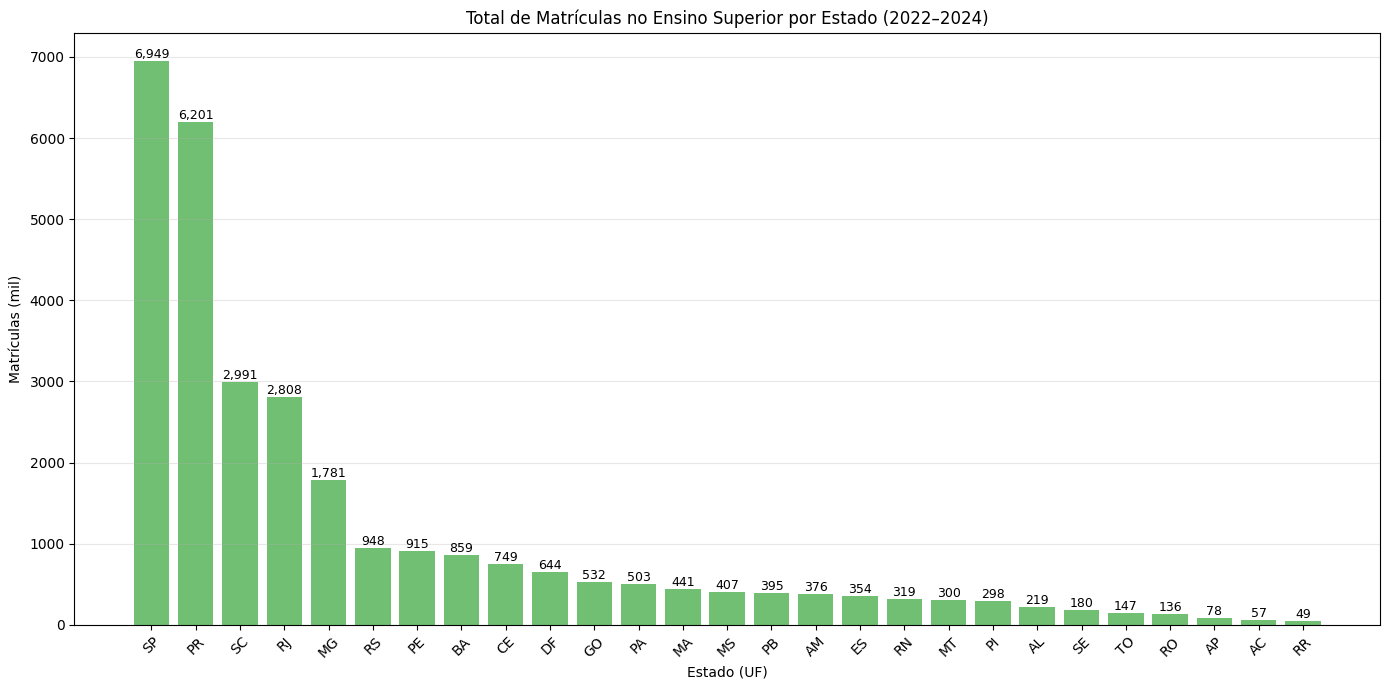


Top 10 estados com mais matrículas:
SG_UF
SP    6949904
PR    6201837
SC    2991488
RJ    2808294
MG    1781506
RS     948093
PE     915085
BA     859416
CE     749893
DF     644651
Name: QT_MAT, dtype: int64


In [6]:
# Total de matrículas por estado
mat_estado = df.groupby('SG_UF')['QT_MAT'].sum().sort_values(ascending=False)

plt.figure(figsize=(14, 7))
bars = plt.bar(mat_estado.index, mat_estado.values / 1_000, color='#4CAF50', alpha=0.8)
plt.xlabel('Estado (UF)')
plt.ylabel('Matrículas (mil)')
plt.title('Total de Matrículas no Ensino Superior por Estado (2022–2024)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}',
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print('\nTop 10 estados com mais matrículas:')
print(mat_estado.head(10))

## 6. Matrículas por Estado e Ano

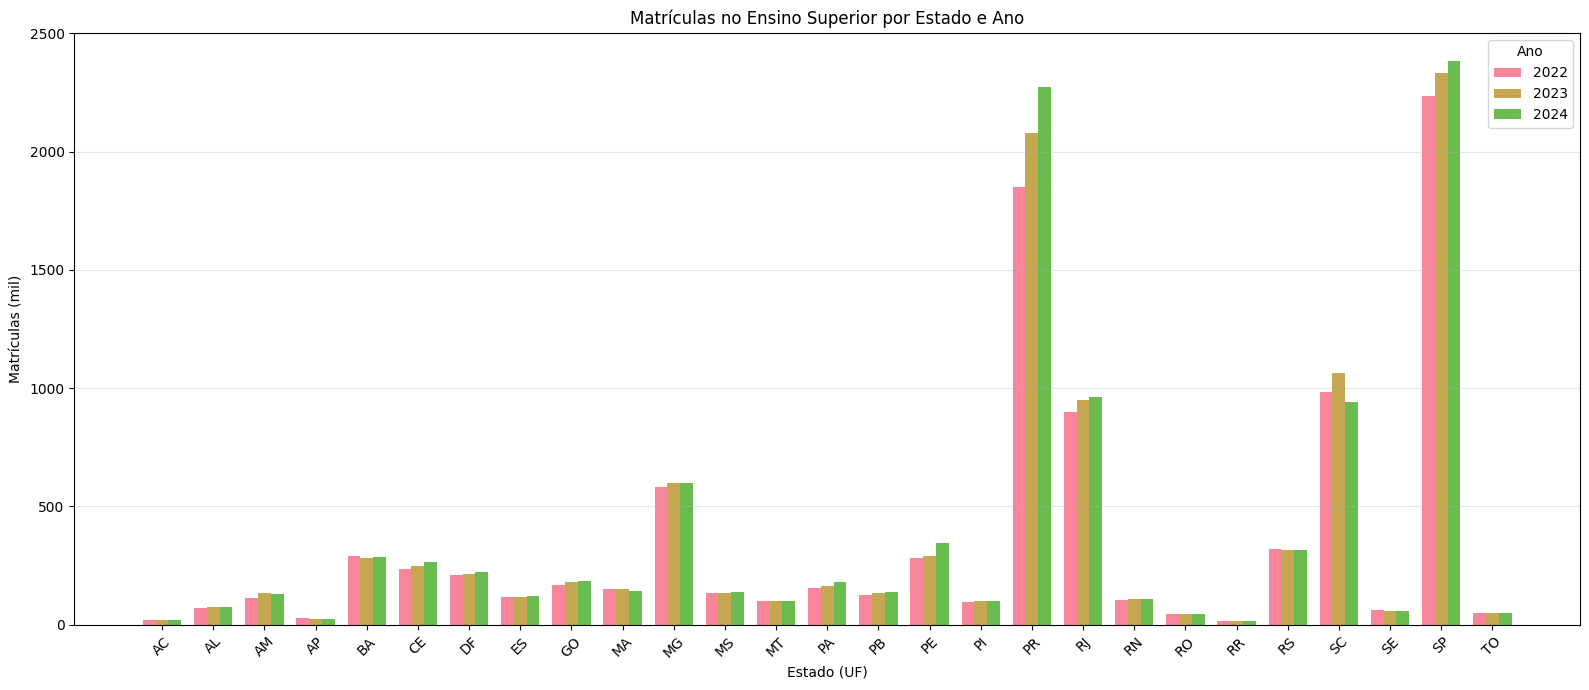

Tabela - Matrículas por Estado e Ano:


ANO,2022,2023,2024
SG_UF,,,
AC,20101,19233,18648
AL,71788,73751,74445
AM,114839,132211,129203
AP,27727,24627,25831
BA,292159,281101,286156
CE,233944,248858,267091
DF,208196,214852,221603
ES,116418,116979,120679
GO,168151,179294,184999


In [7]:
# Pivot: estado × ano
pivot_estado_ano = df.pivot_table(
    index='SG_UF',
    columns='ANO',
    values='QT_MAT',
    aggfunc='sum',
    fill_value=0
).astype(int)

# Gráfico de barras agrupadas por estado
x = range(len(pivot_estado_ano.index))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 7))
for i, ano in enumerate([2022, 2023, 2024]):
    ax.bar([xi + width * (i - 1) for xi in x],
           pivot_estado_ano[ano] / 1_000,
           width, label=str(ano), alpha=0.85)

ax.set_xlabel('Estado (UF)')
ax.set_ylabel('Matrículas (mil)')
ax.set_title('Matrículas no Ensino Superior por Estado e Ano')
ax.set_xticks(x)
ax.set_xticklabels(pivot_estado_ano.index, rotation=45)
ax.legend(title='Ano')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('Tabela - Matrículas por Estado e Ano:')
display(pivot_estado_ano)

## 7. Heatmap — Matrículas por Estado e Ano

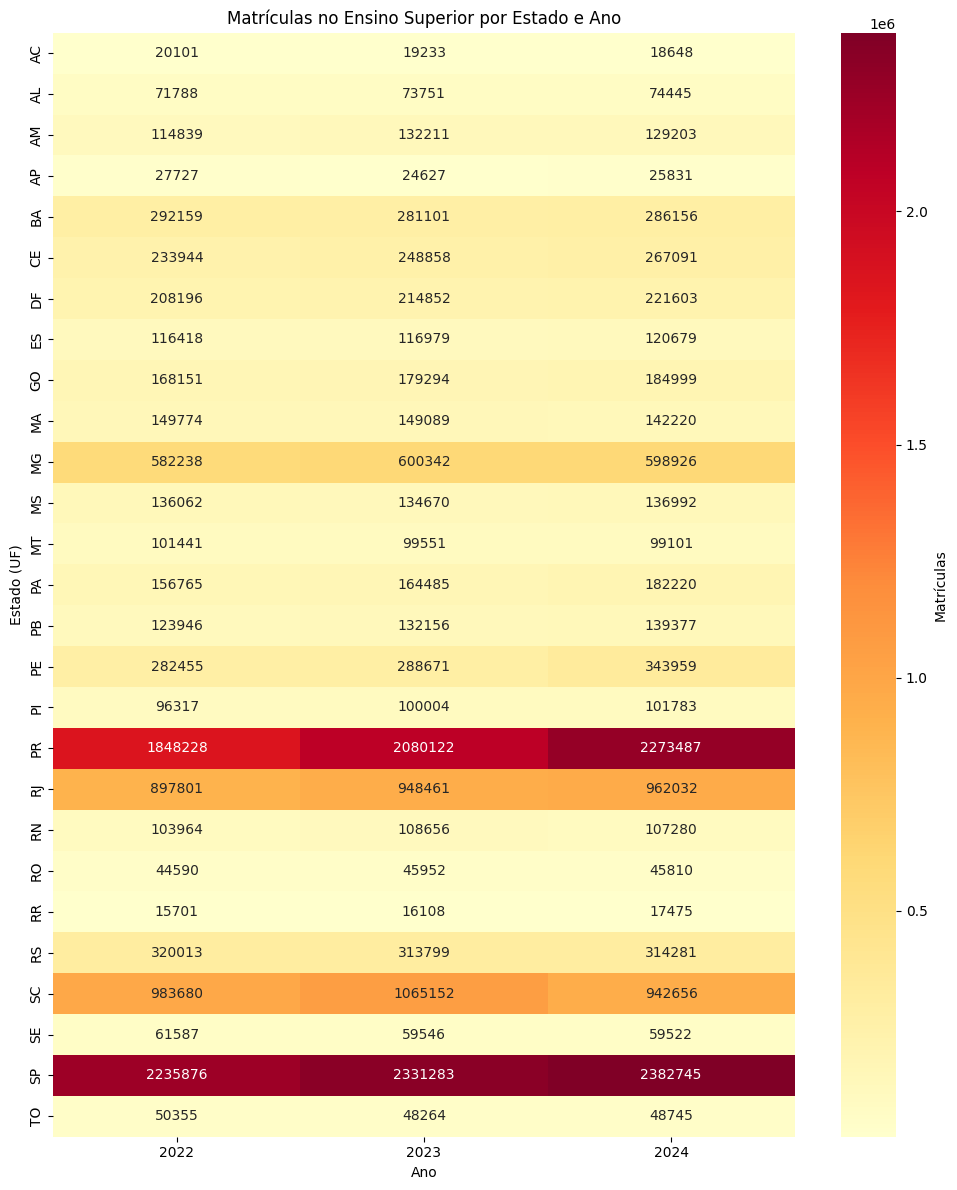

In [8]:
plt.figure(figsize=(10, 12))
sns.heatmap(pivot_estado_ano, annot=True, fmt='d', cmap='YlOrRd',
            cbar_kws={'label': 'Matrículas'})
plt.title('Matrículas no Ensino Superior por Estado e Ano')
plt.xlabel('Ano')
plt.ylabel('Estado (UF)')
plt.tight_layout()
plt.show()

## 8. Top 5 Áreas por Estado (média 2022–2024)

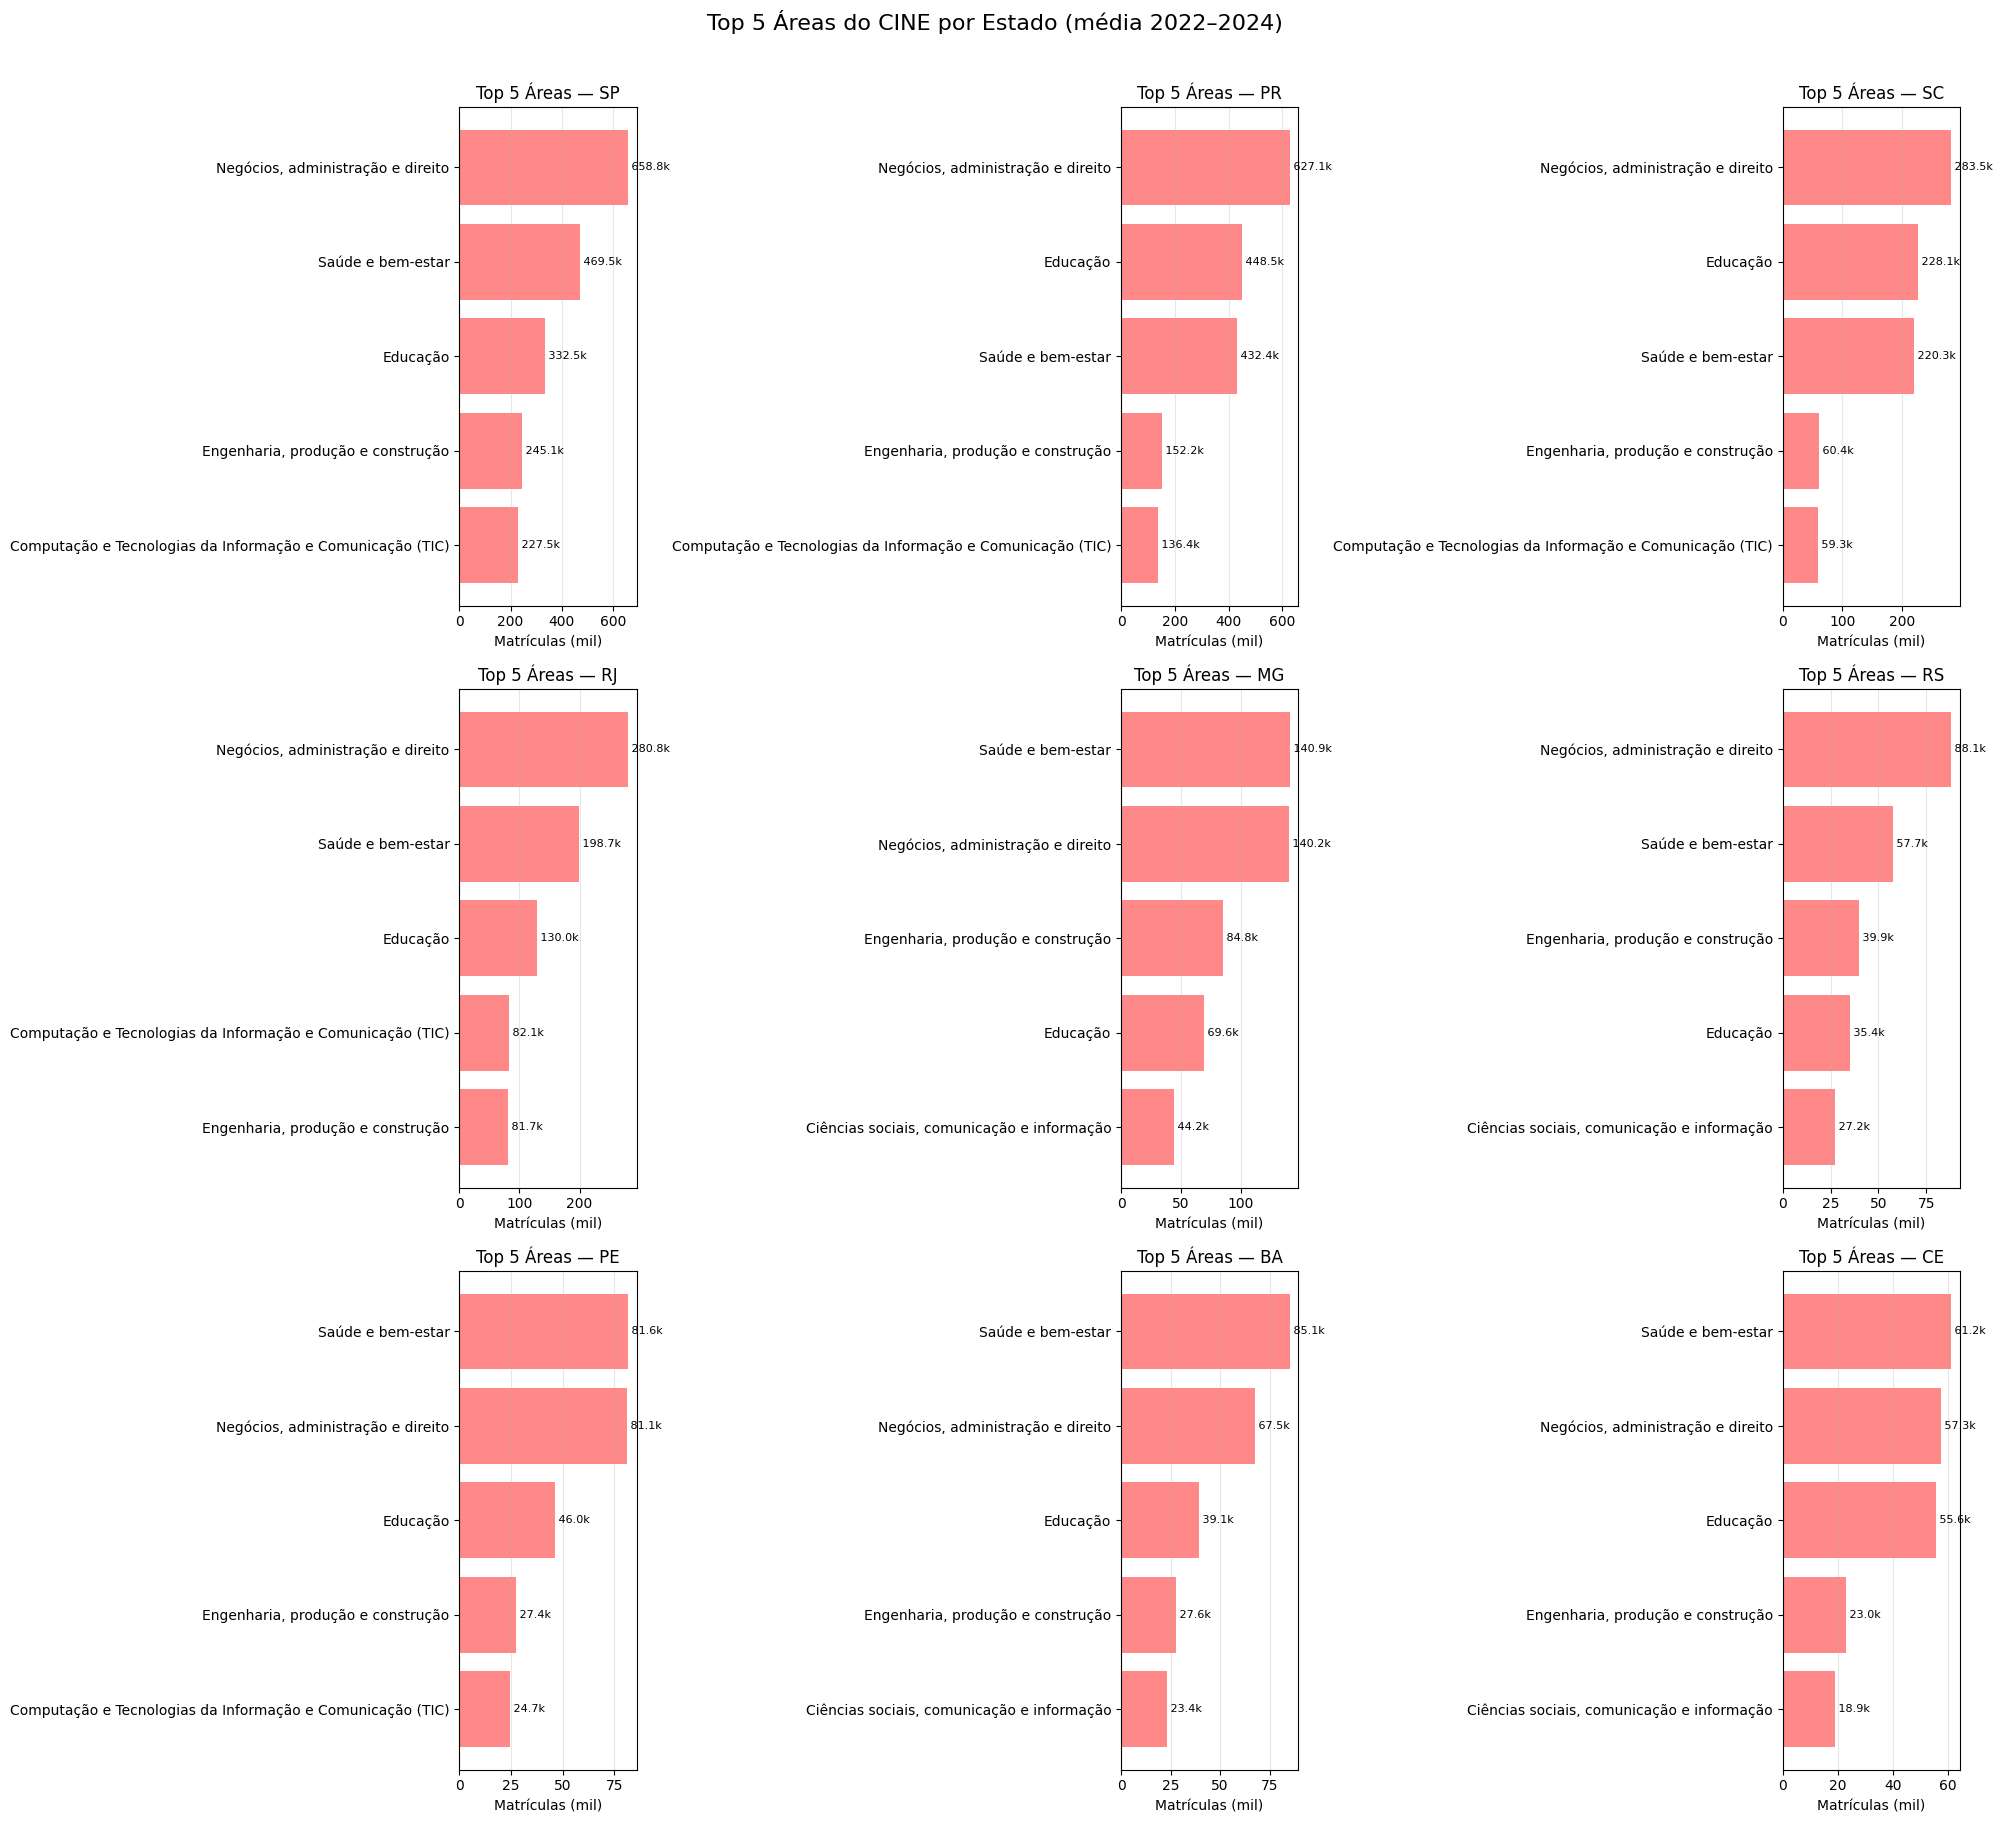

In [9]:
# Para cada estado, mostrar as 5 áreas com mais matrículas (média dos anos)
df_media = df.groupby(['SG_UF', 'NO_CINE_AREA_GERAL'])['QT_MAT'].mean().reset_index()

fig, axes = plt.subplots(3, 3, figsize=(20, 18))
axes = axes.flatten()

# Selecionar os 9 estados com mais matrículas
top_estados = mat_estado.head(9).index.tolist()

for ax, uf in zip(axes, top_estados):
    dados_uf = df_media[df_media['SG_UF'] == uf].sort_values('QT_MAT', ascending=True).tail(5)
    bars = ax.barh(dados_uf['NO_CINE_AREA_GERAL'], dados_uf['QT_MAT'] / 1_000, color='#FF6B6B', alpha=0.8)
    ax.set_title(f'Top 5 Áreas — {uf}')
    ax.set_xlabel('Matrículas (mil)')
    for bar in bars:
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2,
                f' {width:.1f}k', ha='left', va='center', fontsize=8)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Top 5 Áreas do CINE por Estado (média 2022–2024)', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## 9. Evolução das Matrículas por Área ao longo dos Anos

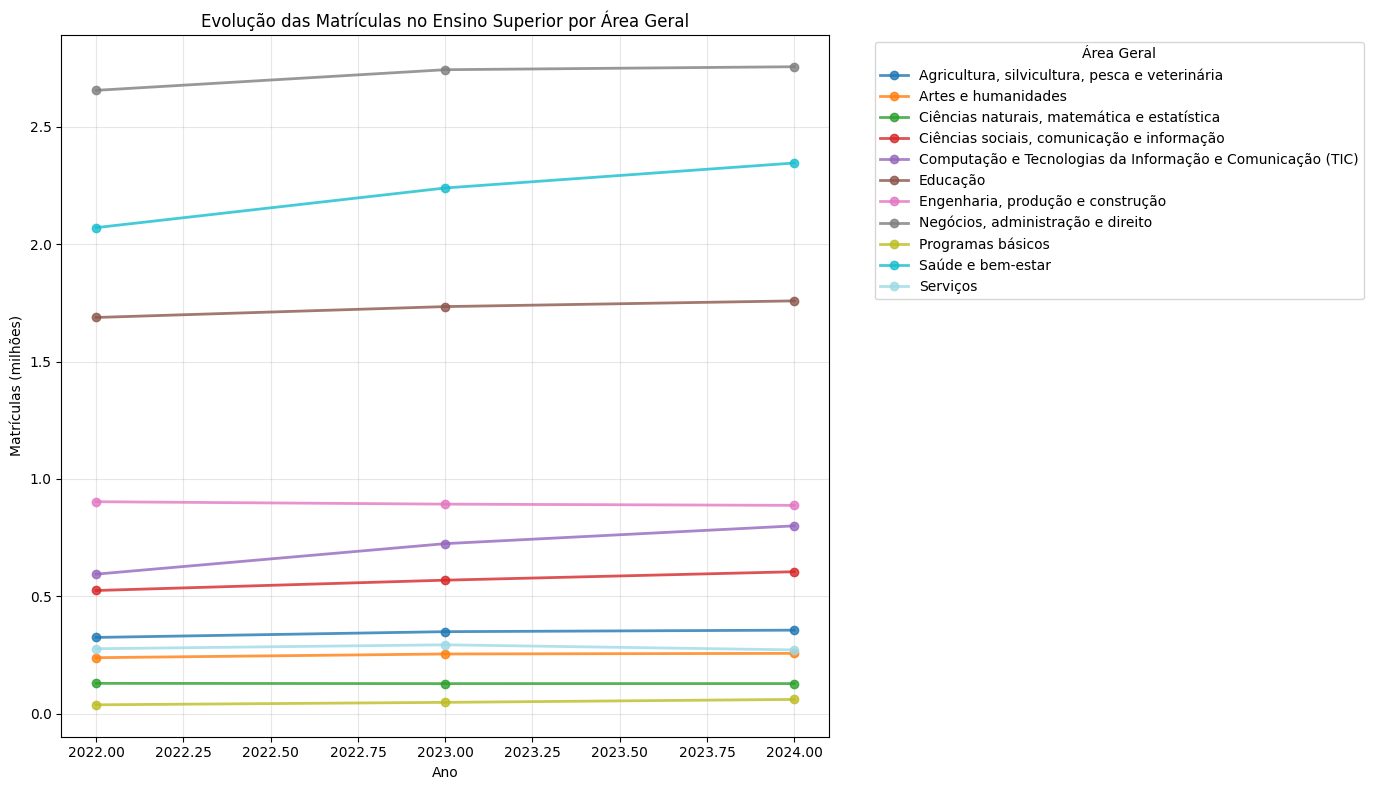

Tabela - Evolução por Área:


ANO,2022,2023,2024
NO_CINE_AREA_GERAL,,,
"Agricultura, silvicultura, pesca e veterinária",325015,349597,356020
Artes e humanidades,238724,254521,257128
"Ciências naturais, matemática e estatística",129425,128240,128443
"Ciências sociais, comunicação e informação",524916,568943,604893
Computação e Tecnologias da Informação e Comunicação (TIC),594580,724485,800222
Educação,1687809,1734150,1758512
"Engenharia, produção e construção",903081,892728,887521
"Negócios, administração e direito",2655174,2743122,2755740
Programas básicos,38004,48464,61053


In [10]:
# Gráfico de linhas: evolução por área
df_evolucao = df.groupby(['NO_CINE_AREA_GERAL', 'ANO'])['QT_MAT'].sum().reset_index()
pivot_evolucao = df_evolucao.pivot(index='NO_CINE_AREA_GERAL', columns='ANO', values='QT_MAT').fillna(0)

plt.figure(figsize=(14, 8))
colors = plt.cm.tab20(np.linspace(0, 1, len(pivot_evolucao.index)))

for idx, area in enumerate(pivot_evolucao.index):
    anos = pivot_evolucao.columns
    vals = pivot_evolucao.loc[area] / 1_000_000
    plt.plot(anos, vals, marker='o', label=area, alpha=0.8, color=colors[idx], linewidth=2)

plt.title('Evolução das Matrículas no Ensino Superior por Área Geral')
plt.xlabel('Ano')
plt.ylabel('Matrículas (milhões)')
plt.legend(title='Área Geral', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Tabela - Evolução por Área:')
display(pivot_evolucao.astype(int))

## 10. Exportar dados consolidados

In [11]:
caminho_saida = f'{data_dir}/df_ensino_superior_area_estado_2022_2024.csv'
df.to_csv(caminho_saida, index=False, encoding='utf-8')
print(f'Dados consolidados salvos em: {caminho_saida}')
print(f'Total de registros: {len(df)}')
print(f'Estados: {sorted(df["SG_UF"].unique())}')
print(f'Anos: {sorted(df["ANO"].unique())}')
print(f'Áreas: {len(df["NO_CINE_AREA_GERAL"].unique())}')

Dados consolidados salvos em: ../data/df_ensino_superior_area_estado_2022_2024.csv
Total de registros: 869
Estados: ['AC', 'AL', 'AM', 'AP', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MG', 'MS', 'MT', 'PA', 'PB', 'PE', 'PI', 'PR', 'RJ', 'RN', 'RO', 'RR', 'RS', 'SC', 'SE', 'SP', 'TO']
Anos: [np.int32(2022), np.int32(2023), np.int32(2024)]
Áreas: 11
